In [1]:
try:
    from google.colab import drive
    IN_COLAB = True
except Exception:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")
    %cd /content/drive/MyDrive/NUIN/CBEM_pytorch
    # !git pull
   

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from utils import *



In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.10.0+cu128
CUDA available: False


## Stim

In [4]:
## Training data
data        = np.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_nr.npz", allow_pickle=True)
stim_mat        = data["stim"]
spk_t      = data['spk_times']
spk_train_mat   = data['spk_train']
V_train  = data['raw_traces'] # shape (N_train, T_v) 

## Test Data
data_test   = np.load("Data/PinkNoise_WholeCell_Light_beta_0_OFF_transient_medium_RF_032025Bc3_rs.npz", allow_pickle=True)
stim_rs        = data_test["stim"]
stimes_rs      = data_test['spk_times']
spk_t_test       = data_test['spk_train']
V_test  = data_test['raw_traces'] # shape (N_test,  T_v)
psth           = np.mean(spk_t_test, axis=0)

In [5]:
dt = 1e-4
# stimulus frames are at 60 Hz
# CBEM runs at 0.1 ms bins, so we upsample stimulus and re-bin spikes from spike times
dt_stim = 1 / 60.0
trial_dur_s = stim_mat.shape[1] * dt_stim

# Trim 0.5 s on each side to avoid edge effects
presamples = int(round(0.5 / dt))
postsamples = int(round(0.5 / dt))

T_cell_full = int(round(trial_dur_s / dt))
bin_edges_s = np.arange(T_cell_full + 1) * dt

def bin_one_trial(spike_times_s, edges_s):
    spikes = np.asarray(spike_times_s, dtype=np.float64)
    counts, _ = np.histogram(spikes, bins=edges_s)
    return counts

def upsample_hold_edges(I_frame, dt_stim_s, dt_cell_s, T_cell):
    t_cell = np.arange(T_cell) * dt_cell_s
    idx = np.floor(t_cell / dt_stim_s).astype(np.int32)
    idx = np.clip(idx, 0, I_frame.shape[-1] - 1)
    return I_frame[..., idx]

def preprocess_split(stim_frames, spk_times_obj, n_trials=None):
    if n_trials is None:
        n_trials = len(spk_times_obj)

    spk_full = np.stack(
        [bin_one_trial(spk_times_obj[trial], bin_edges_s) for trial in range(n_trials)],
        axis=0,
    )
    stim_full = upsample_hold_edges(
        stim_frames[:n_trials], dt_stim_s=dt_stim, dt_cell_s=dt, T_cell=T_cell_full
    )

    t0 = presamples
    t1 = T_cell_full - postsamples
    return stim_full[:, t0:t1], spk_full[:, t0:t1]

# Use all available trials by default
stimulus, spk_train = preprocess_split(stim_mat, spk_t, n_trials=len(spk_t))
stimulus_test, spk_test = preprocess_split(stim_rs, stimes_rs, n_trials=len(stimes_rs))

print('train:', stimulus.shape, spk_train.shape, 'mean rate (Hz):', spk_train.mean() / dt)
print('test :', stimulus_test.shape, spk_test.shape, 'mean rate (Hz):', spk_test.mean() / dt)


train: (11, 100000) (11, 100000) mean rate (Hz): 6.9818181818181815
test : (6, 100000) (6, 100000) mean rate (Hz): 6.7


In [6]:
# spk_train: [B, T]
spkTimes_bins = [np.where(spk_train[trial] > 0)[0] for trial in range(spk_train.shape[0])]

# in ms (since dt_ms is ms/bin)
spkTimes_by_trial = [idx * dt for idx in spkTimes_bins]


In [11]:
spk_idx_trials = [
    torch.as_tensor(np.where(spk_train[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_train.shape[0])
]
len(spk_idx_trials)

spk_idx_test = [
    torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
    for b in range(spk_test.shape[0])
]
len(spk_idx_trials)

11

/tmp/ipykernel_15517/734845851.py:54: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


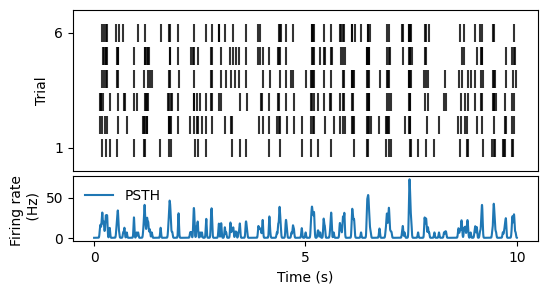

In [50]:
dt_s = dt  # your dt = 1e-4 seconds
spk_t_sec_test = [idx.detach().cpu().numpy() * dt_s for idx in spk_idx_test]  # list of arrays (sec)
psth_hz = spk_test.mean(axis=0) / dt_s   # [T] in Hz
t_sec = np.arange(spk_test.shape[1]) * dt_s
def gaussian_smooth(x, sigma_bins=20):
    # sigma_bins ~ 20 means 20*dt seconds smoothing
    radius = int(4 * sigma_bins)
    k = np.arange(-radius, radius + 1)
    g = np.exp(-0.5 * (k / sigma_bins) ** 2)
    g /= g.sum()
    return np.convolve(x, g, mode="same")

psth_hz_smooth = gaussian_smooth(psth_hz, sigma_bins=int(0.02 / dt_s))  # 20 ms smoothing

import matplotlib.pyplot as plt

B, T = spk_test.shape
t_sec = np.arange(T) * dt_s
psth_hz = spk_test.mean(axis=0) / dt_s
psth_hz_smooth = gaussian_smooth(psth_hz, sigma_bins=max(1, int(0.01 / dt_s)))  # 20 ms

# Optional zoom window (seconds)
tmin, tmax = 0.0, min(5.0, t_sec[-1])  # first 5 seconds

fig, (ax_r, ax_p) = plt.subplots(
    2, 1, figsize=(6, 3),
    sharex=True,
    gridspec_kw={"height_ratios": [2.5, 1.0], "hspace": 0.05}
)

# Raster
ax_r.eventplot(
    spk_t_sec_test,
    lineoffsets=np.arange(1,B+1),
    linelengths=0.8,
    colors="k",
    alpha=0.8,
)
ax_r.set_ylabel("Trial")
ax_r.set_ylim(0, B+1)
ax_r.set_yticks([1,B])
ax_r.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
# ax_r.set_title("Spike raster")

# PSTH
# ax_p.plot(t_sec, psth_hz, alpha=0.35, label="PSTH (raw)")
ax_p.plot(t_sec, psth_hz_smooth, label="PSTH")
ax_p.set_ylabel("Firing rate \n (Hz)")
ax_p.set_xlabel("Time (s)")
ax_p.legend(frameon=False)
ax_p.set_xticks([0,5,10])

# ax_p.set_xlim(tmin, tmax)
plt.tight_layout()
plt.show()

## Train model

In [8]:
# Real data stats + constant-mean baseline log-likelihood

def bernoulli_ll_from_binary(y_bin, p):
    eps = 1e-12
    p = float(np.clip(p, eps, 1.0 - eps))
    return float((y_bin * np.log(p) + (1 - y_bin) * np.log1p(-p)).sum())


def summarize_split(name, spk_counts, dt, p_eval=None):
    # y_bin is what the current loss uses (spike/no-spike per bin)
    y_bin = (spk_counts > 0).astype(np.int64)

    B, T = y_bin.shape
    n_bins = B * T

    spike_bins_per_trial = y_bin.sum(axis=1)
    spikes_per_trial = spk_counts.sum(axis=1)
    multi_spike_bins_per_trial = (spk_counts > 1).sum(axis=1)

    p_hat = float(y_bin.mean())
    lam_hat = -np.log1p(-p_hat)
    rate_hat_hz = lam_hat / dt

    ll_hat = bernoulli_ll_from_binary(y_bin, p_hat)
    nll_hat = -ll_hat

    if p_eval is None:
        p_eval = p_hat
    ll_eval = bernoulli_ll_from_binary(y_bin, p_eval)
    nll_eval = -ll_eval

    print(f'[{name}] trials={B}, bins/trial={T}, duration/trial={T*dt:.3f}s')
    n_idx_trials = len(spk_idx_trials) if name == 'train' else B
    print(f'[{name}] len(spk_idx_trials)={n_idx_trials}')
    print(f'[{name}] spike-bins/trial mean={spike_bins_per_trial.mean():.1f} ± {spike_bins_per_trial.std():.1f}')
    print(f'[{name}] spikes/trial mean={spikes_per_trial.mean():.1f} ± {spikes_per_trial.std():.1f}')
    print(f'[{name}] multi-spike bins/trial mean={multi_spike_bins_per_trial.mean():.1f}')
    print(f'[{name}] mean binary p(y>0)={p_hat:.8f}')
    print(f'[{name}] implied constant rate={rate_hat_hz:.3f} Hz')
    print(f'[{name}] LL@own-mean={ll_hat:.3f} | NLL@own-mean={nll_hat:.3f} | NLL/bin={nll_hat/n_bins:.8f}')

    if abs(float(p_eval) - p_hat) > 1e-15:
        print(f'[{name}] LL@p_eval({p_eval:.8f})={ll_eval:.3f} | NLL@p_eval={nll_eval:.3f} | NLL/bin={nll_eval/n_bins:.8f}')

    print('')
    return {
        'p_hat': p_hat,
        'rate_hat_hz': float(rate_hat_hz),
        'll_hat': ll_hat,
        'nll_hat': nll_hat,
        'n_bins': int(n_bins),
    }


# Train split stats and baseline
train_stats = summarize_split('train', spk_train, dt)

# Test split stats with both its own mean and train-mean evaluated on test
test_stats = summarize_split('test', spk_test, dt, p_eval=train_stats['p_hat'])


[train] trials=11, bins/trial=100000, duration/trial=10.000s
[train] len(spk_idx_trials)=11
[train] spike-bins/trial mean=69.8 ± 5.1
[train] spikes/trial mean=69.8 ± 5.1
[train] multi-spike bins/trial mean=0.0
[train] mean binary p(y>0)=0.00069818
[train] implied constant rate=6.984 Hz
[train] LL@own-mean=-6348.812 | NLL@own-mean=6348.812 | NLL/bin=0.00577165

[test] trials=6, bins/trial=100000, duration/trial=10.000s
[test] len(spk_idx_trials)=6
[test] spike-bins/trial mean=67.0 ± 10.4
[test] spikes/trial mean=67.0 ± 10.4
[test] multi-spike bins/trial mean=0.0
[test] mean binary p(y>0)=0.00067000
[test] implied constant rate=6.702 Hz
[test] LL@own-mean=-3339.775 | NLL@own-mean=3339.775 | NLL/bin=0.00556629
[test] LL@p_eval(0.00069818)=-3340.121 | NLL@p_eval=3340.121 | NLL/bin=0.00556687



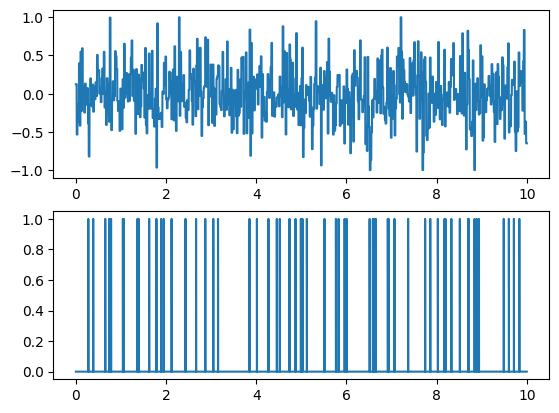

In [9]:
fig, axes = plt.subplots(2,1)
trial =0
t_ms = np.arange(stimulus.shape[1])*dt
axes[0].plot(t_ms, stimulus[trial,:])
axes[1].plot(t_ms, spk_train[trial,:])

# Design Matrices (Train/Test)


In [10]:
nLinearRFs = 10 #;     %number of stimulus basis functions
numShortSHFilts = 5#; %each is 0.4ms long - used for refractory period
nSHfilters = 7+numShortSHFilts#;%7+

nInh = 1#;
nExc = 1#

RFstart = 2e-3 #;%0?
RFend   = 150e-3#;%150e-3 or 180e-3;
b = 0.02
t, B_orth, B_raw = makeRaisedCosBasis(nLinearRFs, dt, [RFstart, RFend], b, zflag=0)
B_orth.shape

(2478, 10)

In [11]:
stimulus_t = torch.as_tensor(stimulus, dtype=torch.float64, device=device)
B_orth_t   = torch.as_tensor(B_orth,   dtype=torch.float64, device=device)
stimulus_t.shape, B_orth_t.shape

(torch.Size([11, 100000]), torch.Size([2478, 10]))

In [12]:
# stimulus_t: [B, T]
# basis_t: [L, P]
X_trials = [
    convolveStimulusWithBasis_torch(stimulus_t[b], B_orth_t, add_ones=True)  # -> [T, P+1]
    for b in range(stimulus_t.shape[0])
]
X_full = torch.stack(X_trials, dim=0)  # [B,T,D]
print('X_full:', X_full.shape)

X_full: torch.Size([11, 100000, 11])


In [13]:

# stimulus_test_t = torch.as_tensor(stimulus_test, dtype=torch.float64, device=device)
# X_test_trials = [
#     convolveStimulusWithBasis_torch(stimulus_test_t[b], B_orth_t, add_ones=True)
#     for b in range(stimulus_test_t.shape[0])
# ]
# X_test_full = torch.stack(X_test_trials, dim=0)  # [B_test,T,D]

# spk_idx_test_trials = [
#     torch.as_tensor(np.where(spk_test[b] > 0)[0], device=device, dtype=torch.long)
#     for b in range(spk_test.shape[0])
# ]

# print('X_full:', X_full.shape, '| X_test_full:', X_test_full.shape)


In [14]:
def cbem_penalized_nll_trials(
    model,
    X_btd: torch.Tensor,                 # [B,T,D]
    spk_bins_list: list[torch.Tensor],   # length B, each [Nspk_b]
    *,
    window: torch.Tensor | None = None,  # [W] indices into time
    conductance_penalty=(0.01, 0.001),
    eps_rate=1e-12,
):
    """
    Penalized NLL across trials. Uses one forward pass.
    """
    B, T, D = X_btd.shape
    device = X_btd.device

    if window is not None:
        X_use = X_btd[:, window, :]           # [B,W,D]
        W = window.numel()
        # shift spikes into local window indices
        spk_use = []
        start = int(window[0].item())
        end   = int(window[-1].item()) + 1
        for b in range(B):
            idx = spk_bins_list[b]
            idxw = idx[(idx >= start) & (idx < end)] - start
            spk_use.append(idxw)
    else:
        X_use = X_btd
        W = T
        spk_use = spk_bins_list

    rate_bt, aux = model(X_use)               # rate [B,W], aux["gs"] [B,W,2]
    gs = aux["gs"]

    # Poisson NLL up to additive constants:
    # sum_t lam - sum_{spikes} log(rate)
    lam = rate_bt * float(model.binsize_s)    # [B,W]
    nll = lam.sum()

        
    for b in range(B):
        idx = spk_use[b]
        if idx.numel() > 0:
            p_spk = (-torch.expm1(-lam[b, idx])).clamp_min(eps_rate)  # 1-exp(-lam)
            nll = nll - torch.log(p_spk).sum()

    lam_e, lam_i = conductance_penalty
    pen = lam_e * gs[..., 0].mean() + lam_i * gs[..., 1].mean()

    return nll / B + pen

In [18]:
def train_cbem_trials(
    model,
    X_cond: torch.Tensor,                 # [B,T,D]
    spkTimes_bins: list[torch.Tensor],    # length B, each 1D long (spike bins)
    *,
    lr=1e-2,
    weight_decay=0.0,
    conductance_penalty=(0.01, 0.001),
    n_steps=2000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,
    seed=0,
):
    torch.manual_seed(seed)
    device = X_cond.device

    if X_cond.ndim != 3:
        raise ValueError(f"X_cond must be [B,T,D], got {X_cond.shape}")
    B, T, D = X_cond.shape
    if len(spkTimes_bins) != B:
        raise ValueError(f"len(spkTimes_bins) must be {B}, got {len(spkTimes_bins)}")

    # Ensure parameters exist (B_cond is lazy)
    with torch.no_grad():
        _ = model(X_cond[:, :10, :])
    print("model device:", next(model.parameters()).device)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    loss_vals, history_steps = [], []

    for step in range(1, n_steps + 1):
        model.train()
        opt.zero_grad(set_to_none=True)

        if window_size is None:
            window = None
        else:
            W = min(int(window_size), T)
            start = torch.randint(low=0, high=max(1, T - W + 1), size=(1,), device=device).item()
            window = torch.arange(start, start + W, device=device, dtype=torch.long)

        loss = cbem_penalized_nll_trials(
            model=model,
            X_btd=X_cond,
            spk_bins_list=spkTimes_bins,
            window=window,
            conductance_penalty=conductance_penalty,
        )

        loss.backward()

        if clip_grad_norm is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=float(clip_grad_norm))

        opt.step()

        if step == 1 or (step % print_every) == 0:
            model.eval()
            with torch.no_grad():
                rate_bt, _ = model(X_cond)  # [B,T]
                lam_bt = rate_bt * float(model.binsize_s)
                mean_rate_hz = float(rate_bt.mean())
                mean_p = float((-torch.expm1(-lam_bt)).mean())
            loss_vals.append(float(loss.detach().cpu()))
            history_steps.append(step)
            print(f"step {step:5d} | loss {float(loss):.3f} | mean rate {mean_rate_hz:.3f} Hz | mean p {mean_p:.6f}")

    return model, (history_steps, loss_vals)

In [62]:
# X_full: [B,T,D]
# spk_idx_trials: list length B, each 1D long tensor of spike indices
model = CBEM_trials(binsize_s=dt).to(device)

trained, (steps_hist, loss_hist) = train_cbem_trials(
    model,
    X_cond=X_full,
    spkTimes_bins=spk_idx_trials,
    lr=3e-2,
    conductance_penalty=(1, 0.2),
    n_steps=1000,
    print_every=100,
    clip_grad_norm=1.0,
    window_size=None,  # or e.g. 20000
)

B_cond_learned = trained.B_cond.detach().cpu()

model device: cuda:0
step     1 | loss 533.692 | mean rate 6.458 Hz | mean p 0.000645
step   100 | loss 533.414 | mean rate 6.674 Hz | mean p 0.000667
step   200 | loss 533.413 | mean rate 6.676 Hz | mean p 0.000667
step   300 | loss 533.413 | mean rate 6.677 Hz | mean p 0.000667
step   400 | loss 533.413 | mean rate 6.677 Hz | mean p 0.000667
step   500 | loss 533.413 | mean rate 6.677 Hz | mean p 0.000667
step   600 | loss 533.413 | mean rate 6.677 Hz | mean p 0.000667
step   700 | loss 533.413 | mean rate 6.677 Hz | mean p 0.000667
step   800 | loss 533.413 | mean rate 6.677 Hz | mean p 0.000667
step   900 | loss 533.413 | mean rate 6.677 Hz | mean p 0.000667
step  1000 | loss 533.413 | mean rate 6.677 Hz | mean p 0.000667


In [70]:
import torch

save_path = "Results/cbem_trials_trained.pt"

ckpt = {
    "model_state_dict": trained.state_dict(),
    "dt": float(dt),
    "binsize_s": float(trained.binsize_s),
    "steps_hist": steps_hist,
    "loss_hist": loss_hist,
    # optional: save learned weights explicitly
    "B_cond": trained.B_cond.detach().cpu(),
}

torch.save(ckpt, save_path)
print("saved to:", save_path)

RuntimeError: Parent directory Results does not exist.

In [67]:
import torch

ckpt = torch.load("cbem_trials_trained.pt", map_location=device)

trained = CBEM_trials(binsize_s=ckpt["binsize_s"]).to(device)

# IMPORTANT: initialize lazy parameter before loading
# (or call model once on dummy input with correct D)
D = ckpt["model_state_dict"]["B_cond"].shape[0]
trained._maybe_init_B_cond_from_D(D, device=device, dtype=torch.float32)

trained.load_state_dict(ckpt["model_state_dict"])
trained.eval()

steps_hist = ckpt.get("steps_hist", None)
loss_hist  = ckpt.get("loss_hist", None)

# Real-Data Evaluation


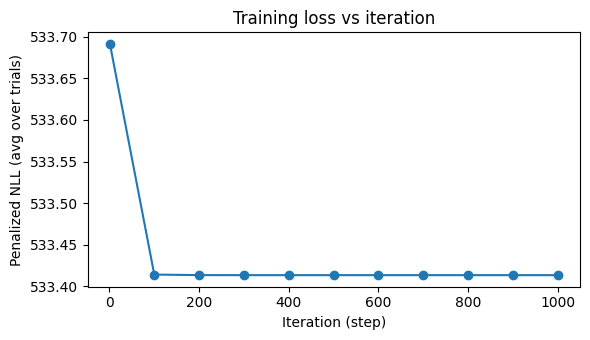

In [63]:
# Training curve
plt.figure(figsize=(6, 3.5))
plt.plot(np.asarray(steps_hist), np.asarray(loss_hist), marker='o')
plt.xlabel('Iteration (step)')
plt.ylabel('Penalized NLL (avg over trials)')
plt.title('Training loss vs iteration')
plt.tight_layout()
plt.show()


In [64]:
def moving_average(x, win_bins):
    win_bins = max(1, int(win_bins))
    if win_bins == 1:
        return x
    k = np.ones(win_bins, dtype=np.float64) / float(win_bins)
    return np.convolve(x, k, mode='same')

def corrcoef_safe(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    if np.std(a) < 1e-12 or np.std(b) < 1e-12:
        return np.nan
    return float(np.corrcoef(a, b)[0, 1])

trained.eval()
with torch.no_grad():
    rate_train_trials, aux = trained(X_full)
    

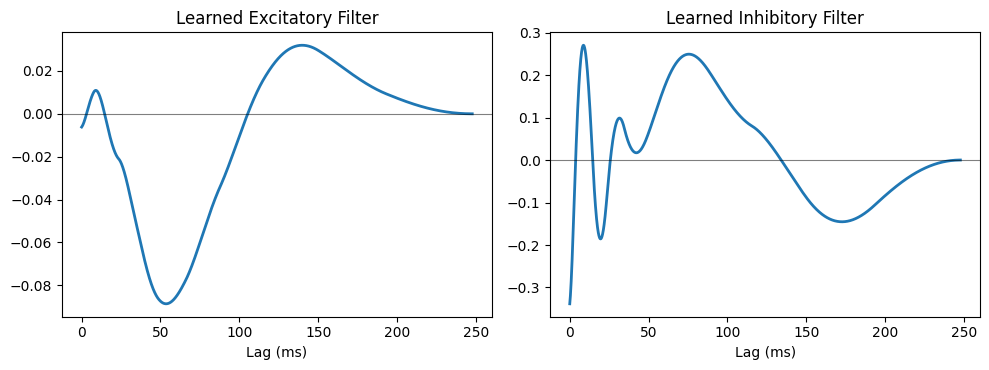

In [65]:
# Learned conductance filters in time domain
B = trained.B_cond.detach().cpu()   # [D, 2]
np.savez("B_trained", B)
W_orth = B[:-1, :]                  # drop bias row

Borth = torch.as_tensor(B_orth, dtype=W_orth.dtype)
filters = Borth @ W_orth            # [L, 2]

t_ms = np.arange(filters.shape[0]) * dt * 1e3

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8))
axes[0].plot(t_ms, filters[:, 0].numpy(), lw=2.0)
axes[0].set_title('Learned Excitatory Filter')
axes[0].set_xlabel('Lag (ms)')

axes[1].plot(t_ms, filters[:, 1].numpy(), lw=2.0)
axes[1].set_title('Learned Inhibitory Filter')
axes[1].set_xlabel('Lag (ms)')

for ax in axes:
    ax.axhline(0.0, color='k', lw=0.8, alpha=0.5)

plt.tight_layout()
plt.show()


# TO do:
- work on initial conditions using linear model
- Add weight freezing functionality
- Data figures